In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

# **Task 1 --  Data Loading & Exploration**

In [4]:
# Load the CSV file using Pandas

df_original = pd.read_csv('HR_Attrition.csv')

df_model = df_original.copy()

In [5]:
# Display the first 10 rows

df_model.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [6]:
# Check how many rows and columns are there

print("No. of rows: ", df_model.shape[0])
print("No. of xolumns: ", df_model.shape[1])

No. of rows:  1470
No. of xolumns:  35


In [7]:
# Identify the target column

print("Target column: ")
df_model['Attrition']

Target column: 


,Attrition
0,Yes
1,No
2,Yes
3,No
4,No
...,...
1465,No
1466,No
1467,No
1468,No


In [8]:
# Count how many employees left vs stayed and calculate the attrition rate as a percentage

df_model['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


Attrition rate = employees who left ÷ total employees.

In [9]:
df_model['Attrition'].count()

np.int64(1470)

In [10]:
attrition_rate = (
    (df_original['Attrition'] == 'Yes').mean()
) * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


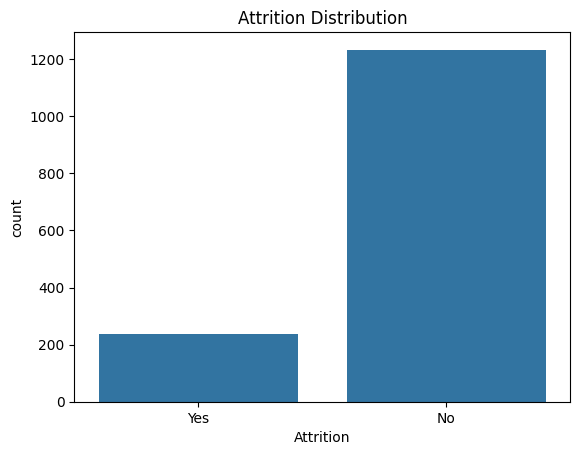

<Figure size 640x480 with 0 Axes>

In [66]:
sns.countplot(
    x='Attrition',
    data=df_original
)
plt.title("Attrition Distribution")
plt.show()

In [12]:
# Identify how many columns are numeric vs categorical

num_cols = df_model.select_dtypes(include = [np.number]).shape[1]
print("Number of nurical columns in the dataset is: ", num_cols)

cat_cols = df_model.select_dtypes(include = ['object']).shape[1]
print("Number of categorical columns in the dataset is: ", cat_cols)

Number of nurical columns in the dataset is:  26
Number of categorical columns in the dataset is:  9


# **Write one observation: what do you notice about the attrition rate — is it balanced or imbalanced?**

As, we look towards the total nummber of employees i.e. 1470 and the number of employee not leaving the oraganization is 1233(employees ho are not leaving), more than the number of emplpoyees who are leaving the organization i.e. 237(employees who are leaving).

This clearly represents that the attrition rate is imbalanced.

# **Task 2 -- Data Cleaning & Preprocessing**

In [13]:
# Check for missing/null values and handle them

df_model.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [14]:
# Drop columns that add no value to prediction (e.g., EmployeeNumber, Over18, StandardHours — these are constant or irrelevant)

drop_cols = [
    'EmployeeNumber',
    'EmployeeCount',
    'Over18',
    'StandardHours'
]

df_model.drop(columns = drop_cols, inplace = True)

In [15]:
df_model.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [16]:
# Convert the target column Attrition from Yes/No to 1/0

df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1,
                     'No': 0})

In [17]:
# Encode all remaining categorical columns using One-Hot Encoding (e.g., Department, JobRole, MaritalStatus, BusinessTravel

df_model = pd.get_dummies(df_model, drop_first = True, dtype = int)

In [18]:
X = df_model.drop(columns = ['Attrition'])
y = df_model['Attrition']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [20]:
# Scale numeric features using StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [21]:
X_train.shape

(1176, 44)

In [22]:
X_test.shape

(294, 44)

In [23]:
X_train

array([[ 1.09019402,  1.04945488, -0.89991452, ..., -0.92144268,
        -0.68154831, -0.63772923],
       [-1.6348276 , -0.52344929, -0.89991452, ...,  1.08525471,
        -0.68154831, -0.63772923],
       [ 0.98119316, -0.99208001, -0.77761018, ...,  1.08525471,
        -0.68154831, -0.63772923],
       ...,
       [-1.6348276 , -1.46320345, -0.16608847, ...,  1.08525471,
        -0.68154831, -0.63772923],
       [-0.10881549, -0.93225481, -0.89991452, ...,  1.08525471,
        -0.68154831,  1.56806362],
       [ 0.21818711, -0.09470203,  1.30156365, ..., -0.92144268,
        -0.68154831, -0.63772923]])

# **Task 3 — Exploratory Data Analysis — EDA**

In [24]:
# Attrition rate by Department — which department loses the most employees?

pd.crosstab(df_original['Department'], df_original['Attrition'])

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


In [25]:
# Attrition rate by Job Role — which roles have the highest exit rate?

department_attrition = (
    df_original
    .groupby('Department')['Attrition']
    .apply(lambda x: (x == 'Yes').mean()*100)
    .sort_values(ascending=False)
)

print(department_attrition)

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


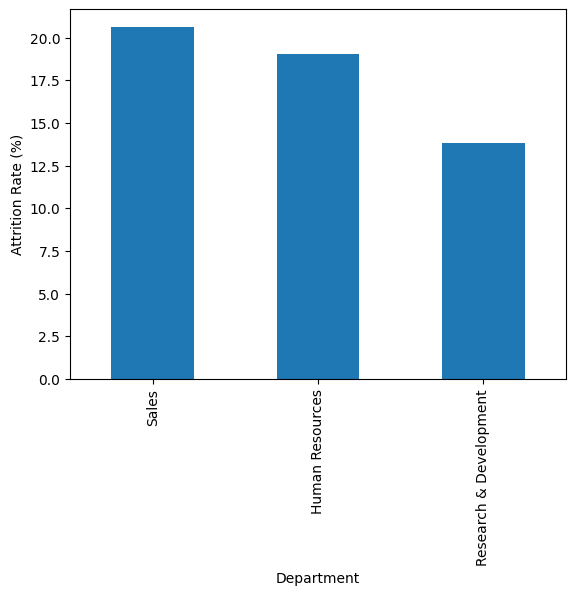

In [72]:
department_attrition.plot(kind='bar')
plt.ylabel("Attrition Rate (%)")
plt.savefig('attrition_vs_dept.png')
plt.show()

In [27]:
jobrole_attrition = (
    df_original
    .groupby('JobRole')['Attrition']
    .apply(lambda x: (x == 'Yes').mean()*100)
    .sort_values(ascending=False)
)

print(jobrole_attrition)

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64


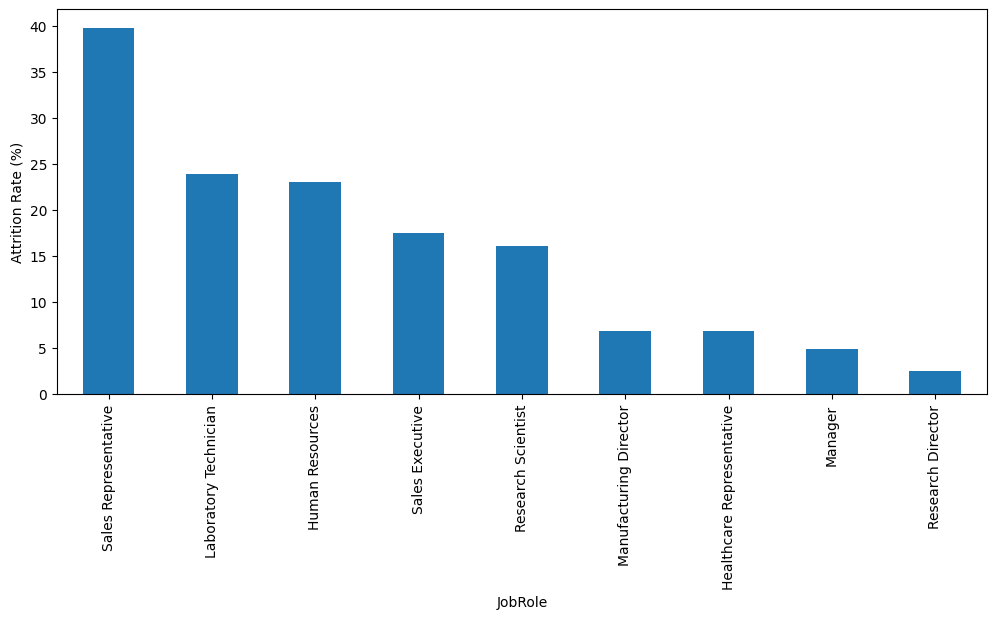

In [71]:
jobrole_attrition.plot(
    kind='bar',
    figsize=(12,5)
)
plt.ylabel("Attrition Rate (%)")
plt.savefig('attrition_vs_jobRole.png')
plt.show()

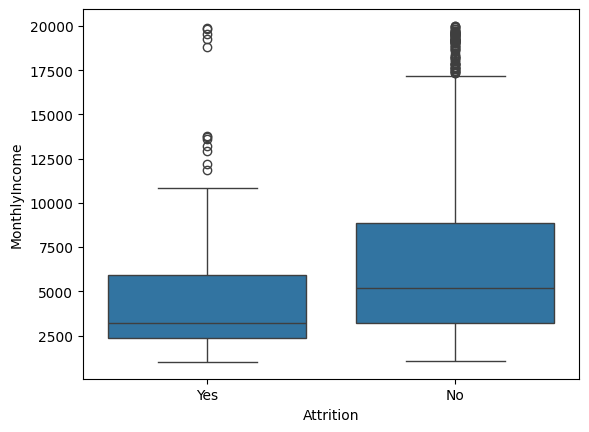

In [70]:
# Attrition vs Monthly Income — do lower paid employees leave more?

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df_original
)

plt.savefig('monthly_income_vs_attrition.png')
plt.show()

In [30]:
df_original.groupby('Attrition')['MonthlyIncome'].median()

,MonthlyIncome
Attrition,
No,5204.0
Yes,3202.0


In [31]:
# Attrition vs Work-Life Balance rating — is there a visible pattern?

wlb_attrition = pd.crosstab(
    df_original['WorkLifeBalance'],
    df_original['Attrition'],
    normalize='index'
) * 100

print(wlb_attrition)

Attrition               No        Yes
WorkLifeBalance                      
1                68.750000  31.250000
2                83.139535  16.860465
3                85.778275  14.221725
4                82.352941  17.647059


<Axes: xlabel='WorkLifeBalance', ylabel='count'>

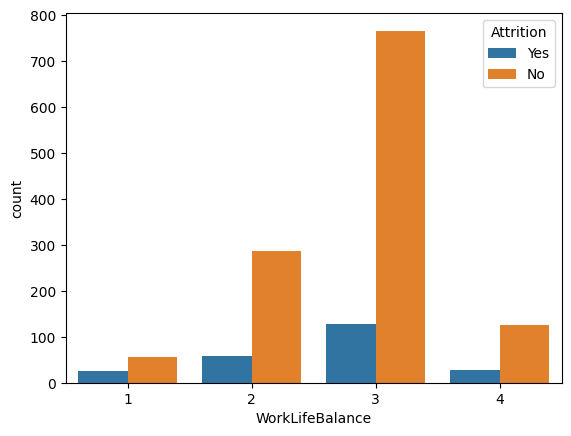

In [32]:
sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=df_original
)

<Axes: xlabel='YearsAtCompany', ylabel='Count'>

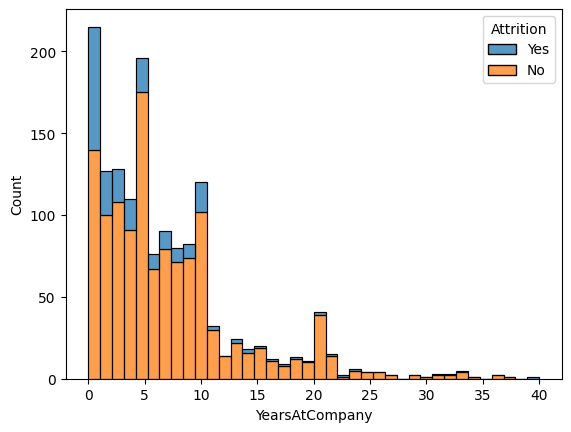

In [33]:
# Attrition vs Years at Company — at what point in tenure do employees leave most?

sns.histplot(
    data=df_original,
    x='YearsAtCompany',
    hue='Attrition',
    multiple='stack'
)

In [34]:
attrition_yes = df_original[
    df_original['Attrition']=='Yes'
]

attrition_yes['YearsAtCompany'].value_counts().sort_index()

,count
YearsAtCompany,
0,16
1,59
2,27
3,20
4,19
5,21
6,9
7,11
8,9


# **Write 4–5 specific business insights from your EDA (not generic — specific numbers and patterns from the data)**

1. **Sales Representatives experienced the highest attrition rate (approximately 39.8%)**, making them the most vulnerable job role in the organization. Laboratory Technicians also showed a relatively high attrition rate (around 23.9%), indicating that these roles require targeted retention strategies.

2. **The Sales department recorded the highest employee attrition among all departments**, suggesting that employees in customer-facing roles may experience greater work pressure, performance targets, or workload compared to other departments.

3. **Employees who left the company generally had lower monthly incomes than employees who stayed**, indicating that compensation may influence attrition. However, income alone is not sufficient to explain employee turnover, as several workplace-related factors also contribute significantly.

4. **Employees with lower Work-Life Balance ratings showed noticeably higher attrition**, suggesting that maintaining a healthy balance between work and personal life is an important factor in employee retention.

5. **Most employees who left the company had relatively fewer years at the organization**, indicating that attrition is highest during the early stages of employment. This suggests that improving onboarding, mentoring, and career development programs during the first few years could reduce employee turnover.


# **Task 4 — Model Building & Comparison**

In [36]:
# Logistic Regression Model

log_reg = LogisticRegression(class_weight = 'balanced', random_state = 42)

In [37]:
log_reg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [38]:
y_pred1 = log_reg.predict(X_test)

In [39]:
y_prob1 = log_reg.predict_proba(X_test)[:,1]

roc_auc_score(
    y_test,
    y_prob1
)

np.float64(0.7982599707123783)

In [40]:
# Random Forest Classifier Model

rfc = RandomForestClassifier(n_estimators = 200, class_weight = 'balanced', random_state = 42)

In [41]:
rfc.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [42]:
y_pred2 = rfc.predict(X_test)

In [43]:
y_prob2 = rfc.predict_proba(X_test)[:,1]

roc_auc_score(
    y_test,
    y_prob2
)

np.float64(0.7688862089757946)

In [44]:
# Gradient Boosting Classifier Model
gbc = GradientBoostingClassifier(random_state = 42)

In [45]:
gbc.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [46]:
y_pred3 = gbc.predict(X_test)

In [47]:
y_prob3 = gbc.predict_proba(X_test)[:,1]

roc_auc_score(
    y_test,
    y_prob3
)

np.float64(0.7941252476526832)

# **Task 5 — Model Evaluation**

In [48]:
# precision_score, f1_score, recall_score, confusion_matrix, roc_auc_score for logistic regression
print('precision score for log_reg : ', precision_score(y_test, y_pred1))
print('recall score for log_reg: ', recall_score(y_test, y_pred1))
print('f1 score for log_reg: ', f1_score(y_test, y_pred1))
print('roc_auc_score for log_reg: ', roc_auc_score(y_test, y_pred1))
print('confusion matrix for log_reg: \n', confusion_matrix(y_test, y_pred1))

precision score for log_reg :  0.34523809523809523
recall score for log_reg:  0.6170212765957447
f1 score for log_reg:  0.44274809160305345
roc_auc_score for log_reg:  0.6971746059092083
confusion matrix for log_reg: 
 [[192  55]
 [ 18  29]]


In [49]:
# precision_score, f1_score, recall_score, confusion_matrix, roc_auc_score for random forest classifier
print('precision score for rfc : ', precision_score(y_test, y_pred2))
print('recall score for rfc: ', recall_score(y_test, y_pred2))
print('f1 score for rfc: ', f1_score(y_test, y_pred2))
print('roc_auc_score for rfc: ', roc_auc_score(y_test, y_pred2))
print('confusion matrix for rfc: \n', confusion_matrix(y_test, y_pred2))

precision score for rfc :  0.5
recall score for rfc:  0.0851063829787234
f1 score for rfc:  0.14545454545454545
roc_auc_score for rfc:  0.5344560254974589
confusion matrix for rfc: 
 [[243   4]
 [ 43   4]]


In [50]:
# precision_score, f1_score, recall_score, confusion_matrix, roc_auc_score for gradient boosting classifier classifier
print('precision score for gbc : ', precision_score(y_test, y_pred3))
print('recall score for gbc : ', recall_score(y_test, y_pred3))
print('f1 score for gbc : ', f1_score(y_test, y_pred3))
print('roc_auc_score for gbc : ', roc_auc_score(y_test, y_pred3))
print('confusion matrix for gbc : \n', confusion_matrix(y_test, y_pred3))

precision score for gbc :  0.5882352941176471
recall score for gbc :  0.2127659574468085
f1 score for gbc :  0.3125
roc_auc_score for gbc :  0.5922129382375743
confusion matrix for gbc : 
 [[240   7]
 [ 37  10]]


In [51]:
# comparison table for all the three models
scores = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Precision': [precision_score(y_test, y_pred1), precision_score(y_test, y_pred2), precision_score(y_test, y_pred3)],
    'Recall': [recall_score(y_test, y_pred1), recall_score(y_test, y_pred2), recall_score(y_test, y_pred3)],
    'F1 Score': [f1_score(y_test, y_pred1), f1_score(y_test, y_pred2), f1_score(y_test, y_pred3)],
    'ROC AUC Score': [roc_auc_score(y_test, y_pred1), roc_auc_score(y_test, y_pred2), roc_auc_score(y_test, y_pred3)]
})

In [52]:
scores

,Model,Precision,Recall,F1 Score,ROC AUC Score
0,Logistic Regression,0.345238,0.617021,0.442748,0.697175
1,Random Forest,0.500000,0.085106,0.145455,0.534456
2,Gradient Boosting,0.588235,0.212766,0.312500,0.592213


# **Identify and clearly state which model performed best and why**

Logistic Regression was selected as the best-performing model. It achieved the highest Recall (61.7%), F1 Score (0.443), and ROC-AUC Score (0.697) among all models tested. Since the business objective is to identify employees at risk of leaving, Recall is particularly important because it measures how many actual attrition cases are correctly detected. Although Gradient Boosting achieved higher Precision, it failed to identify a large proportion of employees who eventually left the company. Therefore, Logistic Regression provides the best balance between predictive performance and business usefulness.

In [53]:
# For the best model: extract Feature Importance — which factors matter most in predicting attrition?

feature_importance = pd.DataFrame({
    'Features': X.columns,
    'Coefficients': log_reg.coef_[0]
})

feature_importance['Importance'] = np.abs(feature_importance['Coefficients'])

feature_importance = feature_importance.sort_values(by = 'Importance', ascending = False)

In [54]:
feature_importance

,Features,Coefficients,Importance
34,JobRole_Laboratory Technician,0.810172,0.810172
43,OverTime_Yes,0.771095,0.771095
23,BusinessTravel_Travel_Frequently,0.722538,0.722538
16,TotalWorkingYears,-0.660270,0.660270
7,JobLevel,0.650173,0.650173
40,JobRole_Sales Representative,0.531090,0.531090
24,BusinessTravel_Travel_Rarely,0.512780,0.512780
27,EducationField_Life Sciences,-0.512319,0.512319
21,YearsSinceLastPromotion,0.499063,0.499063
26,Department_Sales,0.470587,0.470587


In [55]:
positive_features = feature_importance.sort_values(
      by='Coefficients',
          ascending=False
          ).head(10)

negative_features = feature_importance.sort_values(
              by='Coefficients'
              ).head(10)

In [64]:
positive_features

,Features,Coefficients,Importance
34,JobRole_Laboratory Technician,0.810172,0.810172
43,OverTime_Yes,0.771095,0.771095
23,BusinessTravel_Travel_Frequently,0.722538,0.722538
7,JobLevel,0.650173,0.650173
40,JobRole_Sales Representative,0.531090,0.531090
24,BusinessTravel_Travel_Rarely,0.512780,0.512780
21,YearsSinceLastPromotion,0.499063,0.499063
26,Department_Sales,0.470587,0.470587
11,NumCompaniesWorked,0.464327,0.464327
42,MaritalStatus_Single,0.455366,0.455366


In [65]:
negative_features

,Features,Coefficients,Importance
16,TotalWorkingYears,-0.660270,0.660270
27,EducationField_Life Sciences,-0.512319,0.512319
22,YearsWithCurrManager,-0.461322,0.461322
29,EducationField_Medical,-0.452134,0.452134
4,EnvironmentSatisfaction,-0.434370,0.434370
8,JobSatisfaction,-0.393219,0.393219
30,EducationField_Other,-0.389932,0.389932
37,JobRole_Research Director,-0.388326,0.388326
6,JobInvolvement,-0.285370,0.285370
0,Age,-0.266981,0.266981


Risk factors (positive coefficients): increase the likelihood of attrition.

Protective factors (negative coefficients): decrease the likelihood of attrition.

In [56]:
# Rank the top 10 most important features driving employee exit

feature_importance.head(10)

,Features,Coefficients,Importance
34,JobRole_Laboratory Technician,0.810172,0.810172
43,OverTime_Yes,0.771095,0.771095
23,BusinessTravel_Travel_Frequently,0.722538,0.722538
16,TotalWorkingYears,-0.660270,0.660270
7,JobLevel,0.650173,0.650173
40,JobRole_Sales Representative,0.531090,0.531090
24,BusinessTravel_Travel_Rarely,0.512780,0.512780
27,EducationField_Life Sciences,-0.512319,0.512319
21,YearsSinceLastPromotion,0.499063,0.499063
26,Department_Sales,0.470587,0.470587


# **Task 6 — Visualization**

Text(0.5, 1.0, 'Attrition Rate by Department')

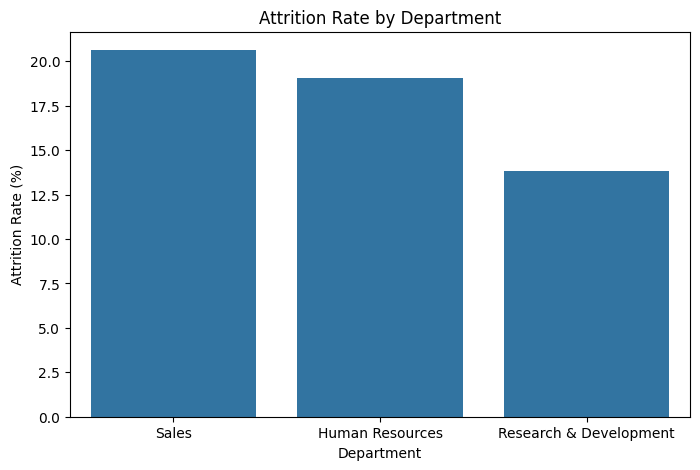

In [57]:
#1. Bar chart showing attrition rate by Department and Job Role

department_attrition = (
    df_original.groupby('Department')['Attrition']
    .apply(lambda x: (x == 'Yes').mean()*100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values
)

plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Department")

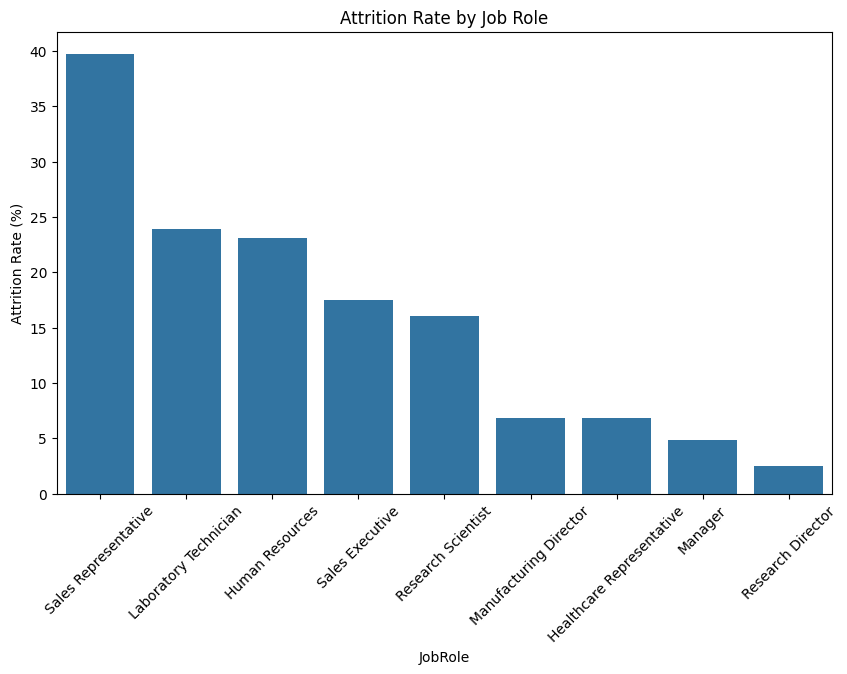

In [58]:
#1. Bar chart showing attrition rate by Department and Job Role

job_role_attrition = (
    df_original.groupby('JobRole')['Attrition']
    .apply(lambda x: (x == 'Yes').mean()*100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=job_role_attrition.index,
    y=job_role_attrition.values
)

plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Job Role")
plt.xticks(rotation = 45)
plt.show()

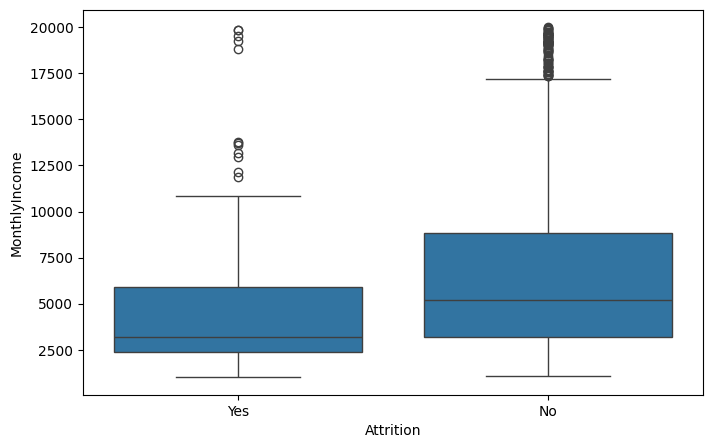

In [59]:
# Chart 2: Box plot comparing Monthly Income of employees who left vs stayed

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df_original
)

plt.show()

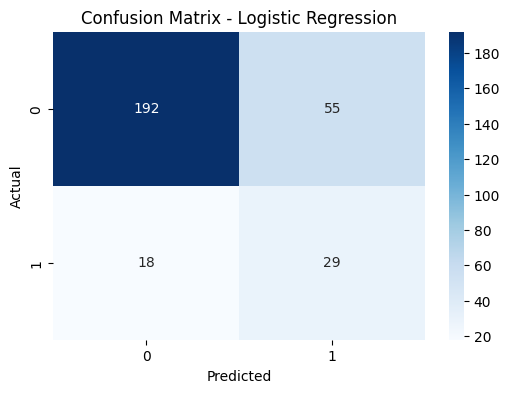

In [73]:
# Chart 3: Confusion Matrix heatmap for your best model

cm = confusion_matrix(y_test, log_reg.predict(X_test))

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig('conf_matrix.png')
plt.show()

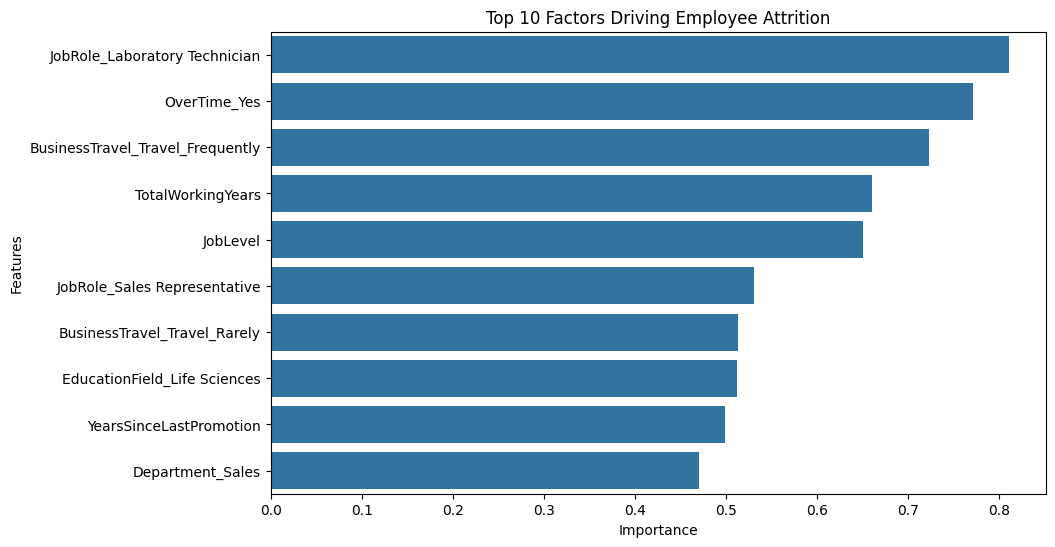

In [74]:
# Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model

top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Importance',
    y='Features'
)

plt.title("Top 10 Factors Driving Employee Attrition")
plt.savefig('top10_emp_attrition.png')
plt.show()

In [62]:
# Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph

lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob1)

rf_fpr, rf_tpr, _ = roc_curve(y_test, y_prob2)

gbc_fpr, gbc_tpr, _ = roc_curve(y_test, y_prob3)

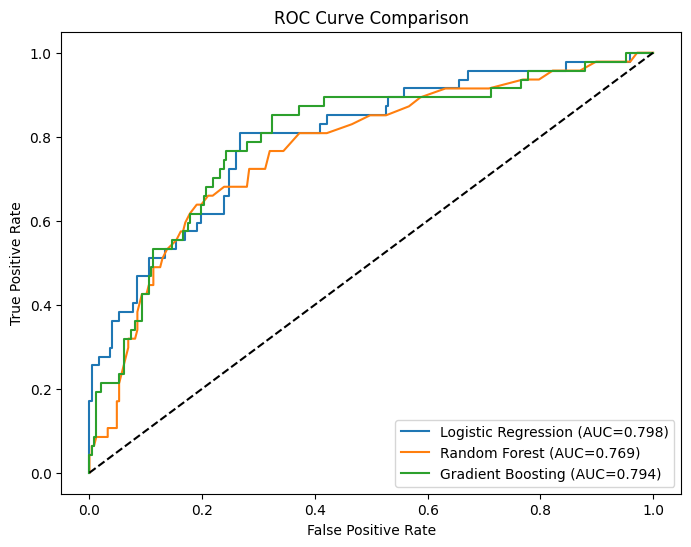

In [75]:
plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob1):.3f})'
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob2):.3f})'
)

plt.plot(
    gbc_fpr,
    gbc_tpr,
    label=f'Gradient Boosting (AUC={roc_auc_score(y_test, y_prob3):.3f})'
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.savefig('roc_curve_comp.png')
plt.show()

# **Task 7 — HR Insights & Business Recommendations**

**●	Which 3 factors most strongly predict that an employee will leave?**

Working as a Laboratory Technician, which showed the highest positive influence on attrition prediction.

Working Overtime, indicating that employees who regularly work overtime are more likely to leave the organization.

Frequent Business Travel, suggesting that employees who travel frequently for work have a higher risk of attrition.

**●	Which department or job role should HR prioritize for retention efforts?**

The exploratory data analysis showed that Sales Representatives have the highest actual attrition rate among all job roles. The Sales department also appears as an important predictor in the machine learning model. Therefore, HR should prioritize retention efforts for employees working in Sales, particularly Sales Representatives, while also monitoring Laboratory Technicians, as the prediction model identifies this role as a strong indicator of future attrition risk.

**●	Does salary alone explain attrition or are there other stronger factors?**

No. Salary alone does not explain employee attrition. The analysis indicates that workplace factors such as overtime, business travel frequency, promotion delays, job satisfaction, and work environment satisfaction have a stronger influence on whether an employee leaves the company. Improving these workplace conditions may be more effective than focusing only on salary increases.

**●	Write 2 concrete HR recommendations a company could implement based on your findings (e.g., specific policy changes, who to target for a retention conversation)**

**Recommendation 1:**

Identify employees who frequently work overtime or travel regularly and conduct periodic one-on-one retention discussions. Introducing flexible work arrangements, balanced workloads, and improved work-life balance policies may help reduce voluntary attrition.

**Recommendation 2:**

Review promotion and career development policies for employees who have remained in the same position for long periods. Providing clear career growth opportunities, regular performance feedback, and internal mobility programs can improve employee retention, particularly in Sales-related roles.

**●	What limitation does this model have that an HR team should be aware of before using it?**

Although the model provides useful predictions, it should be used as a decision-support tool rather than as the sole basis for HR decisions. Employee attrition can also be influenced by personal circumstances, organizational culture, leadership quality, and external job opportunities, none of which are captured in the available dataset. Therefore, HR should combine model predictions with managerial judgment and employee feedback before taking action.